In [2]:
#relevant libraries
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
import sklearn.linear_model as sk

In [3]:
#preprocessing
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
file_path = "mnist.npz"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with np.load(file_path) as data:
    x_train, y_train = data['x_train'], data['y_train']
    x_test, y_test = data['x_test'], data['y_test']

train_mask = np.isin(y_train, [0, 1, 2])
test_mask = np.isin(y_test, [0, 1, 2])

x_train_filtered = x_train[train_mask]
y_train_filtered = y_train[train_mask]

x_test_filtered = x_test[test_mask]
y_test_filtered = y_test[test_mask]

x_train_flat = x_train_filtered.reshape(x_train_filtered.shape[0], -1)
x_test_flat = x_test_filtered.reshape(x_test_filtered.shape[0], -1)

x_train_processed = x_train_flat.astype(np.float32) / 255.0
x_test_processed = x_test_flat.astype(np.float32) / 255.0

print(f"Original Training set shape: {x_train.shape}, {y_train.shape}")
print(f"Original Test set shape: {x_test.shape}, {y_test.shape}")
print()
print(f"Filtered Training set shape (classes 0, 1, 2): {x_train_filtered.shape}, {y_train_filtered.shape}")
print(f"Filtered Test set shape (classes 0, 1, 2): {x_test_filtered.shape}, {y_test_filtered.shape}")
print()
print(f"Processed Training set shape (flattened): {x_train_processed.shape}")
print(f"Processed Test set shape (flattened): {x_test_processed.shape}")
print(f"Pixel value range: [{x_train_processed.min()}, {x_train_processed.max()}]")

Original Training set shape: (60000, 28, 28), (60000,)
Original Test set shape: (10000, 28, 28), (10000,)

Filtered Training set shape (classes 0, 1, 2): (18623, 28, 28), (18623,)
Filtered Test set shape (classes 0, 1, 2): (3147, 28, 28), (3147,)

Processed Training set shape (flattened): (18623, 784)
Processed Test set shape (flattened): (3147, 784)
Pixel value range: [0.0, 1.0]


In [4]:
def compute_mean(data_matrix):
    return np.mean(data_matrix, axis=0)

def compute_covariance(data_matrix):
    N = data_matrix.shape[0]
    return (data_matrix.T @ data_matrix) / (N - 1)
    
def pca(samples, variance=1.0, components=0):
    print(f"Training set shape ({samples.shape[0]},{samples.shape[1]})")
    
    #mean and center data
    mean = compute_mean(samples)
    print(f"Mean shape {mean.shape}")
    centered_data_mat = samples - mean
    print(f"Centered data matrix shape {centered_data_mat.shape}")
    
    #covariance matrix
    covariance = compute_covariance(centered_data_mat)
    print(f"Centered data matrix shape {covariance.shape}")
    
    
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.maximum(eigenvalues, 0)
            
    #eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    #variance preservation
    if 0 < variance < 1:
        explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        retain_indices = np.argmax(cumulative_variance >= variance) + 1
        return sorted_eigenvectors[:, :retain_indices]

    #pca components
    elif 0 < components < sorted_eigenvectors.shape[1]:
        return sorted_eigenvectors[:, :components]

    return sorted_eigenvectors

def apply_pca(samples, w, mean):
    samples = samples - mean
    return samples @ w

In [12]:
def ridge_regression(samples,labels,lmbda):
    N = samples.shape[0]
    w = np.linalg.inv((samples.T @ samples)+ lmbda*np.eye(samples.shape[1])) @ samples.T @ labels 
    #print(f"Ridge regression w shape: {w.shape}")
    return w

def lasso_regression(samples,labels,lmbda):
    w = sk.Lasso(alpha=lmbda).fit(samples,labels).coef_.T
    #print(f"Lasso regression w shape: {w.shape}")
    return w
    
def mse(samples, labels, w):
    y_pred = samples @ w
    return np.mean((labels - y_pred)**2)
    
def training(x_train,y_train, x_test, y_test):
    class_wise_train = []
    class_wise_test = []
    for i in (0,1,2):
        class_wise_train.append(np.isin(y_train, [i]).astype(float))
        class_wise_test.append(np.isin(y_test, [i]).astype(float))

    y_train = np.vstack([i for i in class_wise_train]).T
    y_test = np.vstack([i for i in class_wise_test]).T

    #print(f"{x_train.shape} is x train")
    #print(f"{y_train.shape} is y train")

    mse_store = {}
    ridge_reg_path = []
    lasso_reg_path = []

    w_pca = pca(x_train, components=10)
    #print(f"{w_pca.shape}")
    mean = np.mean(x_train, axis=0)
    x_train = apply_pca(x_train, w_pca, mean)
    x_test = apply_pca(x_test, w_pca, mean)

    lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

    for lmbda in lambdas:       
        w_ridge = ridge_regression(x_train, y_train, lmbda)
        w_lasso = lasso_regression(x_train, y_train, lmbda)
        
        non_zero_coeff = w_lasso.size - np.sum(np.isclose(w_lasso, [0]))
        ridge_reg_path.append(w_ridge[:, 0])
        lasso_reg_path.append(w_lasso[:, 0])

        mse_train_ridge = mse(x_train, y_train, w_ridge)
        mse_train_lasso = mse(x_train, y_train, w_lasso)
        
        mse_val_ridge = mse(x_test, y_test, w_ridge)
        mse_val_lasso = mse(x_test, y_test, w_lasso)

        mse_store[lmbda] = {'train_ridge':mse_train_ridge, 'test_ridge':mse_val_ridge, 'train_lasso':mse_train_lasso, 'test_lasso':mse_val_lasso, 'lasso_non_zero': non_zero_coeff}

    ridge_reg_path = np.array(ridge_reg_path).T
    lasso_reg_path = np.array(lasso_reg_path).T

    plt.figure(figsize=(18, 10))

    # 1. mse ridge
    plt.subplot(2, 3, 1)
    plt.plot(lambdas, [mse_store[l]['train_ridge'] for l in lambdas], marker='o', label='Train MSE')
    plt.plot(lambdas, [mse_store[l]['test_ridge'] for l in lambdas], marker='s', label='Test MSE')
    plt.xscale('log')
    plt.xlabel('Lambda')
    plt.ylabel('Mean Squared Error')
    plt.title('Ridge Regression MSE')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2. mse lasso
    plt.subplot(2, 3, 2)
    plt.plot(lambdas, [mse_store[l]['train_lasso'] for l in lambdas], marker='o', label='Train MSE')
    plt.plot(lambdas, [mse_store[l]['test_lasso'] for l in lambdas], marker='s', label='Test MSE')
    plt.xscale('log')
    plt.xlabel('Lambda')
    plt.ylabel('Mean Squared Error')
    plt.title('Lasso Regression MSE')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 3. Log lambda vs Lasso non-zero coefficients
    plt.subplot(2, 3, 3)
    plt.plot(lambdas, [mse_store[l]['lasso_non_zero'] for l in lambdas], marker='^', color='green')
    plt.xscale('log')
    plt.xlabel('Lambda')
    plt.ylabel('Count of Non-Zero Coefficients')
    plt.title('Lambda bs')
    plt.grid(True, linestyle='--', alpha=0.7)

    # ridge reg path
    plt.subplot(2, 3, 4)
    for i in range(ridge_reg_path.shape[0]):
        plt.plot(lambdas, ridge_reg_path[i, :])
    plt.xscale('log')
    plt.xlabel('Lambda vs Non-Zero Coefficients')
    plt.ylabel('Coefficient Value')
    plt.title('Ridge Regularization Path (Class 0)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # lasso reg path
    plt.subplot(2, 3, 5)
    for i in range(lasso_reg_path.shape[0]):
        plt.plot(lambdas, lasso_reg_path[i, :])
    plt.xscale('log')
    plt.xlabel('Lambda')
    plt.ylabel('Coefficient Value')
    plt.title('Lasso Regularization Path (Class 0)')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()      

    return mse_store

Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)


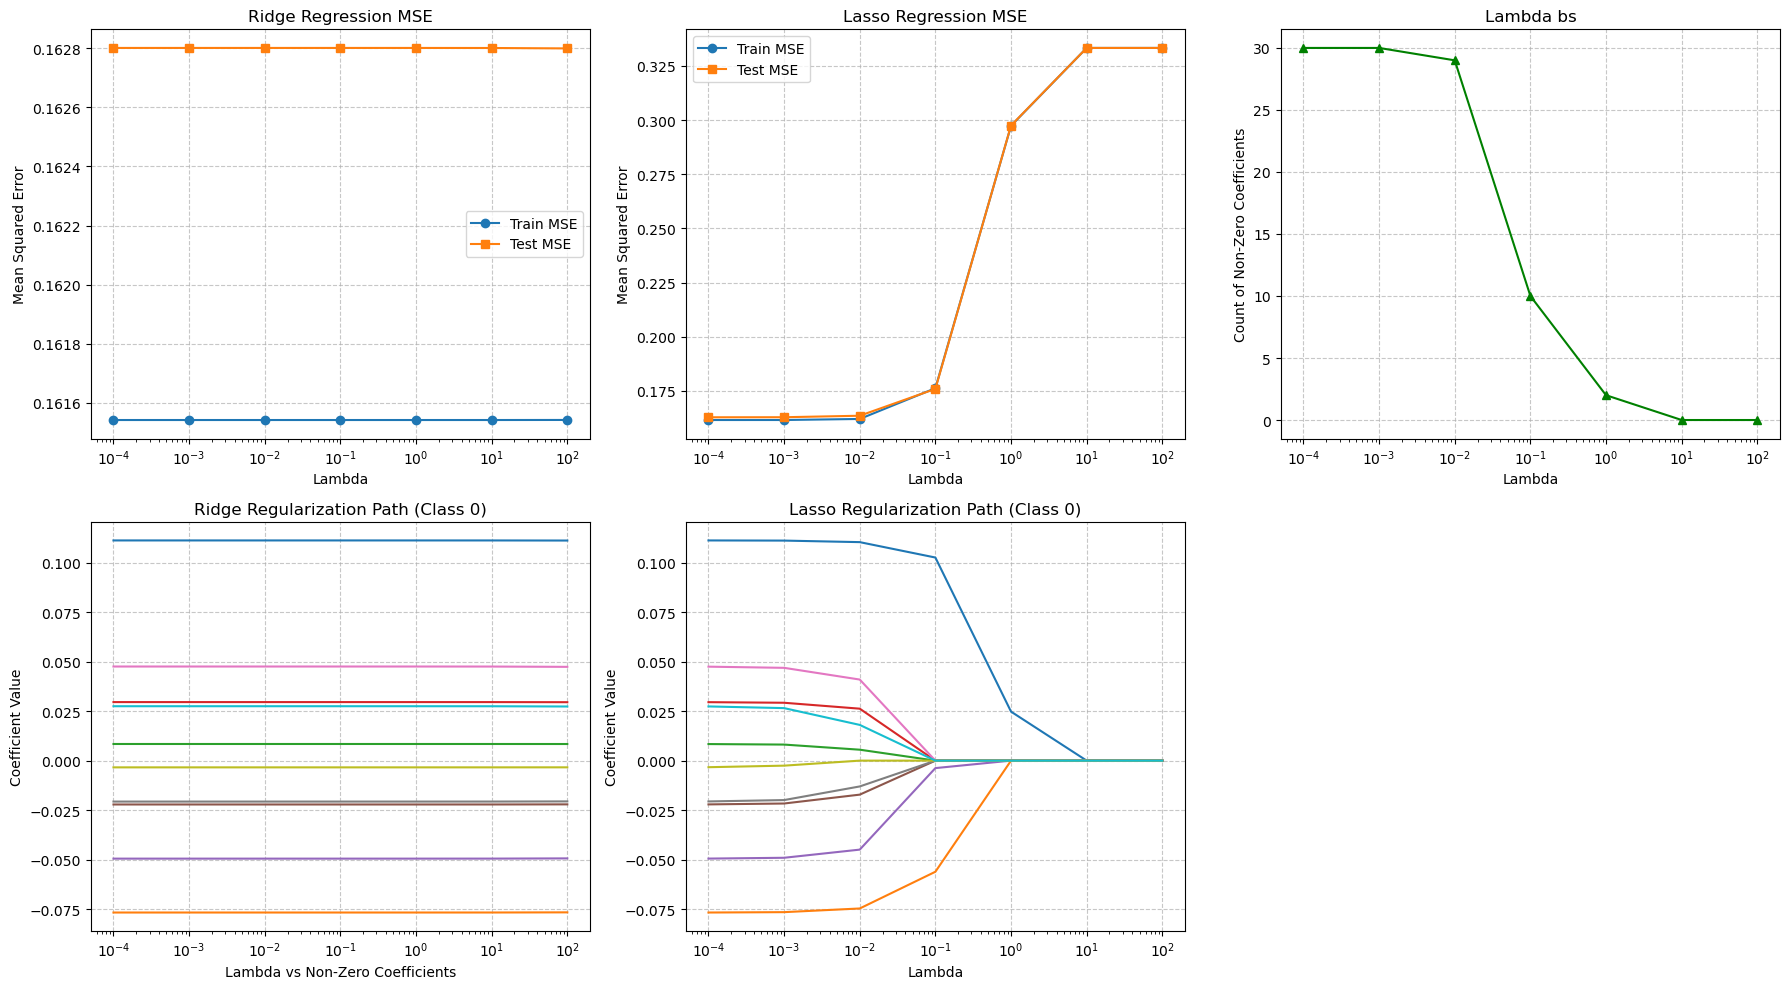

{0.0001: {'train_ridge': 0.16154236944285172,
  'test_ridge': 0.1628007966709392,
  'train_lasso': 0.16154241950646256,
  'test_lasso': 0.16280304812584656,
  'lasso_non_zero': 30},
 0.001: {'train_ridge': 0.16154236944285183,
  'test_ridge': 0.16280079665464292,
  'train_lasso': 0.1615474620997794,
  'test_lasso': 0.16283065911388778,
  'lasso_non_zero': 30},
 0.01: {'train_ridge': 0.1615423694428549,
  'test_ridge': 0.1628007964916819,
  'train_lasso': 0.16202805775847232,
  'test_lasso': 0.16351934868575624,
  'lasso_non_zero': 29},
 0.1: {'train_ridge': 0.16154236944306974,
  'test_ridge': 0.1628007948622502,
  'train_lasso': 0.17623341756395233,
  'test_lasso': 0.17591357692582377,
  'lasso_non_zero': 10},
 1: {'train_ridge': 0.16154236946364597,
  'test_ridge': 0.16280077858579248,
  'train_lasso': 0.29739285316894304,
  'test_lasso': 0.29751167944794105,
  'lasso_non_zero': 2},
 10: {'train_ridge': 0.16154237151142478,
  'test_ridge': 0.16280061760641631,
  'train_lasso': 0.3333

In [13]:
training(x_train_processed,y_train_filtered, x_test_processed, y_test_filtered)

In [14]:
def train_vary_complexity(x_train,y_train, x_test, y_test, lmbda):
    class_wise_train = []
    class_wise_test = []
    for i in (0,1,2):
        class_wise_train.append(np.isin(y_train, [i]).astype(float))
        class_wise_test.append(np.isin(y_test, [i]).astype(float))

    y_train = np.vstack([i for i in class_wise_train]).T
    y_test = np.vstack([i for i in class_wise_test]).T

    print(f"{x_train.shape} is x train")
    print(f"{y_train.shape} is y train")

    mse_store = {}
    pca_values = [2,5,10,20,30]
    mean = np.mean(x_train, axis = 0)

    for pca_comp in pca_values:
        w_pca = pca(x_train, components = pca_comp)
        print(w_pca.shape)
        x_train_after_pca = apply_pca(x_train, w_pca, mean)
        x_test_after_pca = apply_pca(x_test, w_pca, mean)
        
        w_ridge = ridge_regression(x_train_after_pca, y_train, lmbda)
        
        mse_train_ridge = mse(x_train_after_pca, y_train, w_ridge)
        mse_val_ridge = mse(x_test_after_pca, y_test, w_ridge)

        mse_store[pca_comp] = {'train_ridge':mse_train_ridge, 'test_ridge':mse_val_ridge}

    train_errors = [mse_store[i]['train_ridge'] for i in mse_store]
    test_errors = [mse_store[i]['test_ridge'] for i in mse_store]

    plt.figure(figsize=(8, 5))
    plt.plot(pca_values, train_errors, marker='o', label='Train MSE', color='blue')
    plt.plot(pca_values, test_errors, marker='s', label='Test MSE', color='orange')
    plt.xlabel('Model Complexity (Number of PCA Dimensions $p$)')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Ridge Regression: MSE vs Complexity (lambda = {lmbda})')
    plt.xticks(pca_values)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

(18623, 784) is x train
(18623, 3) is y train
Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
(784, 2)
Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
(784, 5)
Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
(784, 10)
Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
(784, 20)
Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
(784, 30)


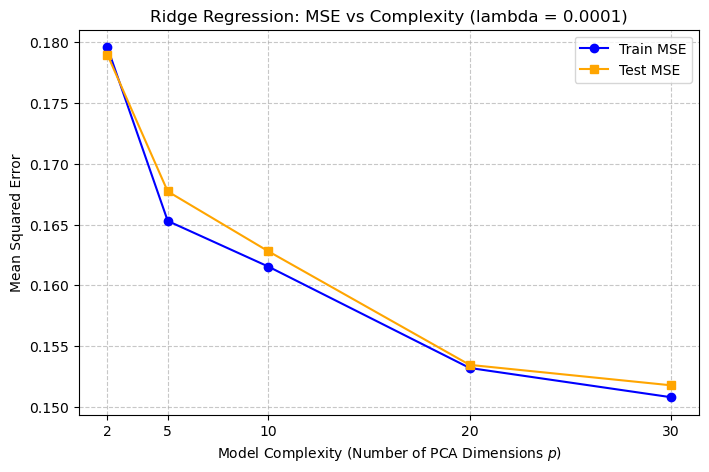

In [17]:
train_vary_complexity(x_train_processed,y_train_filtered, x_test_processed, y_test_filtered,1e-4)

In [26]:
def classify(x_train, y_train, x_test, y_test, comp, lmbda):
    class_wise_train = []
    class_wise_test = []
    for i in (0,1,2):
        class_wise_train.append(np.isin(y_train, [i]).astype(float))
        class_wise_test.append(np.isin(y_test, [i]).astype(float))

    y_train = np.vstack([i for i in class_wise_train]).T
    y_test = np.vstack([i for i in class_wise_test]).T

    w_pca = pca(x_train, components=comp)
    mean = np.mean(x_train, axis=0)
    x_train = apply_pca(x_train, w_pca, mean)
    x_test = apply_pca(x_test, w_pca, mean)

    w_ridge = ridge_regression(x_train, y_train, lmbda)
    w_lasso = lasso_regression(x_train, y_train, lmbda)

    y_pred_train_ridge = np.argmax(x_train @ w_ridge, axis = 1)
    y_pred_test_ridge = np.argmax(x_test @ w_ridge, axis= 1)
    y_pred_train_lasso = np.argmax(x_train @ w_lasso, axis = 1)
    y_pred_test_lasso = np.argmax(x_test @ w_lasso, axis= 1)
    y_train = np.argmax(y_train, axis=1)
    y_test = np.argmax(y_test, axis=1)
    
    print("Train Ridge Error: ",np.mean(y_pred_train_ridge == y_train)*100, "%")
    print("Test Ridge Error:", np.mean(y_pred_test_ridge == y_test)*100, "%")
    print("Train Lasso Error:", np.mean(y_pred_train_lasso == y_train)*100, "%")
    print("Test Lasso Error:", np.mean(y_pred_test_lasso == y_test)*100, "%")

In [29]:
classify(x_train_processed,y_train_filtered, x_test_processed, y_test_filtered,30,1e-4)

Training set shape (18623,784)
Mean shape (784,)
Centered data matrix shape (18623, 784)
Centered data matrix shape (784, 784)
Train Ridge Error:  96.50969231595339 %
Test Ridge Error: 96.37750238322211 %
Train Lasso Error: 96.50969231595339 %
Test Lasso Error: 96.37750238322211 %
